In [19]:
import numpy as np 
import pandas as pd

data = pd.read_csv("../data/train_FD001.txt", sep=r'\s+')

column_names = ["unit_number", "time_in_cycles", "op_settings_1", "op_settings_2", "op_settings_3"]
column_names += [f'sensor_{i}' for i in range(1, 22)]  
data.columns = column_names


pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

data.head()

,unit_number,time_in_cycles,op_settings_1,op_settings_2,op_settings_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
1,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
2,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
3,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
4,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,21.61,554.67,2388.02,9049.68,1.3,47.16,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669


In [25]:
engine_count = len(data)

print("The total number of engines is", engine_count)

cycles_per_engine = data.groupby('unit_number')['time_in_cycles'].max()

print("There are", len(cycles_per_engine), "groups of engines in total")

print("The engines are not unifrom in length")

print("The longest engine lifespan is", cycles_per_engine.max())

print("The shortest engine lifespan is", cycles_per_engine.min())

print("The average engine lifespan is", cycles_per_engine.mean())





The total number of engines is 20630
There are 100 groups of engines in total
The engines are not unifrom in length
The longest engine lifespan is 362
The shortest engine lifespan is 128
The average engine lifespan is 206.31


In [ ]:
missing = data.isnull().sum()

Na = missing.sum()

print("There are", Na, "missing values")

sensors = [f'sensor_{i}' for i in range(1, 22)]  

sensor_data = data[sensors].agg(['mean', 'min', 'max'])

print("""Some sensors have major variation, some sensors have minor variation, 
and some sensors have no variation at all.""")

op1 = data['op_settings_1'].nunique()
op2 = data['op_settings_2'].nunique()
op3 = data['op_settings_3'].nunique()

print("operation settings #1 has", op1, "unique value(s)")
print("operation settings #2 has", op2, "unique value(s)")
print("operation settings #3 has", op3, "unique value(s)")

sensor_data

There are 0 missing values
Some sensors have major variation, some sensors have minor variation, 
and some sensors have no variation at all.
operation settings #1 has 158 unique value(s)
operation settings #2 has 13 unique value(s)
operation settings #3 has 1 unique value(s)


,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
mean,518.67,642.680975,1590.523159,1408.934186,14.62,21.609803,553.367663,2388.096653,9065.243864,1.3,47.541172,521.413458,2388.096156,8143.752971,8.442147,0.03,393.210713,2388.0,100.0,38.816259,23.289699
min,518.67,641.210000,1571.040000,1382.250000,14.62,21.600000,549.850000,2387.900000,9021.730000,1.3,46.850000,518.690000,2387.880000,8099.940000,8.324900,0.03,388.000000,2388.0,100.0,38.140000,22.894200
max,518.67,644.530000,1616.910000,1441.490000,14.62,21.610000,556.060000,2388.560000,9244.590000,1.3,48.530000,523.380000,2388.560000,8293.720000,8.584800,0.03,400.000000,2388.0,100.0,39.430000,23.618400


In [51]:
clean_data = data.drop(['op_settings_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19'], axis=1)
print("Data after the coloumns with no unique values were removed")
clean_data.head()

Data after the coloumns with no unique values were removed


,unit_number,time_in_cycles,op_settings_1,op_settings_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
1,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
2,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
3,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044
4,1,6,-0.0043,-0.0001,642.10,1584.47,1398.37,21.61,554.67,2388.02,9049.68,47.16,521.68,2388.03,8132.85,8.4108,391,38.98,23.3669


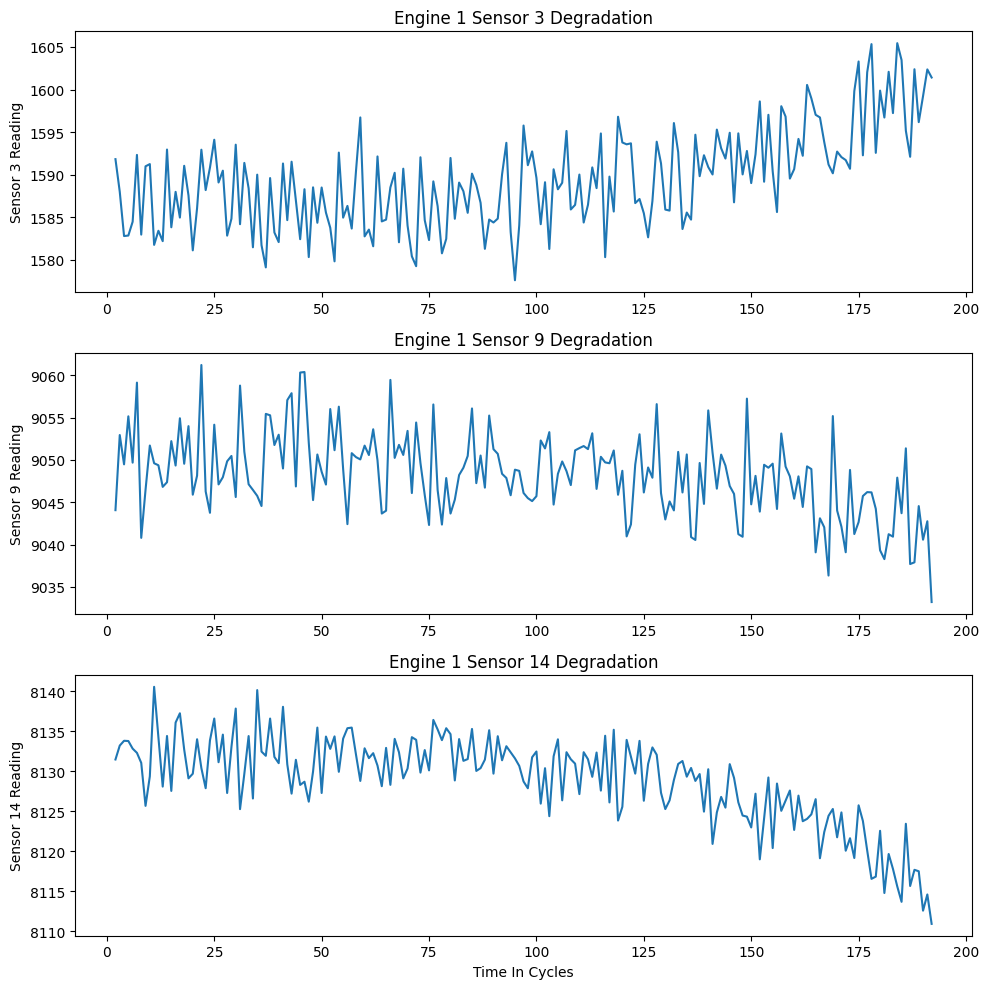

In [71]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

engine_1 = clean_data[clean_data['unit_number'] == 1][['time_in_cycles', 'sensor_3', 'sensor_9', 'sensor_14']]

axes[0].plot(engine_1['time_in_cycles'], engine_1['sensor_3'])
axes[0].set_ylabel('Sensor 3 Reading')
axes[0].set_title('Engine 1 Sensor 3 Degradation')

axes[1].plot(engine_1['time_in_cycles'], engine_1['sensor_9'])
axes[1].set_ylabel('Sensor 9 Reading')
axes[1].set_title('Engine 1 Sensor 9 Degradation')

axes[2].plot(engine_1['time_in_cycles'], engine_1['sensor_14'])
axes[2].set_ylabel('Sensor 14 Reading')
axes[2].set_title('Engine 1 Sensor 14 Degradation')


plt.xlabel('Time In Cycles')
plt.tight_layout()